In [12]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
%matplotlib inline

from warnings import filterwarnings
filterwarnings('ignore')

In [13]:
from collections import Counter
from sklearn.datasets import make_classification

## Create the dataset
X, y = make_classification(n_samples=10000, n_features=2,n_clusters_per_class=1, n_redundant=0,weights=[0.99], random_state=42)

In [14]:
Counter(y)

Counter({np.int64(0): 9859, np.int64(1): 141})

<Axes: xlabel='0', ylabel='1'>

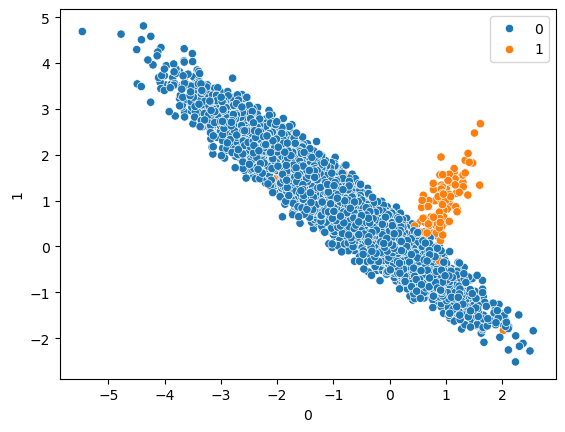

In [15]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [17]:
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [18]:
## Hyperparamter tuning
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
penalty=['l1', 'l2', 'elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [19]:
params=dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1.0, 0.1, 0.01],
 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)
grid.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [21]:
grid.best_params_

{'C': 1.0,
 'class_weight': {0: 1, 1: 10},
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [22]:
grid.best_score_

np.float64(0.9951428571428572)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, balanced_accuracy_score

y_pred = grid.predict(X_test)

score = balanced_accuracy_score(y_test, y_pred)
print("Accuracy Score:", score)
cm = confusion_matrix(y_test, y_pred)
print("\n",cm)
print("\n",classification_report(y_test, y_pred))

Accuracy Score: 0.8402562125786255

 [[2952    1]
 [  15   32]]

               precision    recall  f1-score   support

           0       0.99      1.00      1.00      2953
           1       0.97      0.68      0.80        47

    accuracy                           0.99      3000
   macro avg       0.98      0.84      0.90      3000
weighted avg       0.99      0.99      0.99      3000

